# **Marketing Campaign Performance Insights**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## ***1) Load the Dataset***

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/ArchanaInsights/Datasets/main/marketing_campaign.csv")

## ***2) Descriptive Analysis***

### **Basic Structure:**

In [3]:
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,TechCorp,Email,Women 25-34,30 days,Facebook,5.294194,9344,62.94,Houston,English,3045,67836,5,Tech Enthusiasts,01-01-2023
1,2,Innovate Industries,Influencer,Women 35-44,45 days,Google Ads,3.326375,8783,10.67,"Washington, D.C.",German,1944,66361,4,Foodies,01-01-2023
2,3,NexGen Systems,Social Media,Women 25-34,45 days,Instagram,4.056375,9111,73.20,Miami,Spanish,3156,86240,8,Fashionistas,01-01-2023
3,4,Innovate Industries,Email,Women 25-34,45 days,Instagram,4.496375,7420,60.92,Seattle,Spanish,2388,58251,6,Foodies,01-01-2023
4,5,Data Tech Solutions,Influencer,Men 25-34,30 days,Google Ads,4.405930,2146,138.82,Chicago,English,1025,34407,5,Tech Enthusiasts,01-01-2023


In [4]:
df.shape

(22029, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22029 entries, 0 to 22028
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       22029 non-null  int64  
 1   Company           22029 non-null  object 
 2   Campaign_Type     22029 non-null  object 
 3   Target_Audience   22029 non-null  object 
 4   Duration          22029 non-null  object 
 5   Channel_Used      22029 non-null  object 
 6   Conversion_Rate   22029 non-null  float64
 7   Acquisition_Cost  22029 non-null  int64  
 8   ROI               22029 non-null  float64
 9   Location          22029 non-null  object 
 10  Language          22029 non-null  object 
 11  Clicks            22029 non-null  int64  
 12  Impressions       22029 non-null  int64  
 13  Engagement_Score  22029 non-null  int64  
 14  Customer_Segment  22029 non-null  object 
 15  Date              22029 non-null  object 
dtypes: float64(2), int64(5), object(9)
memor

In [6]:
df.select_dtypes(include='number').columns

Index(['Campaign_ID', 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Clicks',
       'Impressions', 'Engagement_Score'],
      dtype='object')

In [7]:
num_col = ['Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Clicks', 'Impressions', 'Engagement_Score']
num_col

['Conversion_Rate',
 'Acquisition_Cost',
 'ROI',
 'Clicks',
 'Impressions',
 'Engagement_Score']

In [8]:
df[num_col].describe().astype(int)

,Conversion_Rate,Acquisition_Cost,ROI,Clicks,Impressions,Engagement_Score
count,22029,22029,22029,22029,22029,22029
mean,4,5522,182,2223,50610,6
std,0,2597,301,1394,28542,1
min,2,1000,-98,30,1001,4
25%,4,3286,-4,1067,25804,5
50%,4,5525,93,2088,50858,7
75%,5,7766,247,3212,75165,8
max,7,9999,3109,6887,99999,9


### **Data Exploration:**

In [9]:
df['Campaign_ID'].nunique()

22029

In [10]:
unique = ['Location', 'Customer_Segment']

In [11]:
for i in unique:
  print(f'{i} Column Unique Values: {df[i].unique()}\n')

Location Column Unique Values: ['Houston' 'Washington, D.C.' 'Miami' 'Seattle' 'Chicago' 'Los Angeles'
 'Atlanta' 'Dallas' 'New York' 'San Francisco']

Customer_Segment Column Unique Values: ['Tech Enthusiasts' 'Foodies' 'Fashionistas' 'Outdoor Adventurers'
 'Health & Wellness']



In [12]:
values = ['Campaign_Type', 'Channel_Used']

In [13]:
for a in values:
    print(f'Column Value Count: {df[a].value_counts()}\n')

Column Value Count: Campaign_Type
Display         4450
Search          4441
Social Media    4412
Email           4388
Influencer      4338
Name: count, dtype: int64

Column Value Count: Channel_Used
Facebook      3742
Google Ads    3694
Website       3688
Instagram     3649
YouTube       3632
Email         3624
Name: count, dtype: int64



## ***3) Exploratory Data Analysis (EDA) and Visualization***

### **Campaign Performance:**

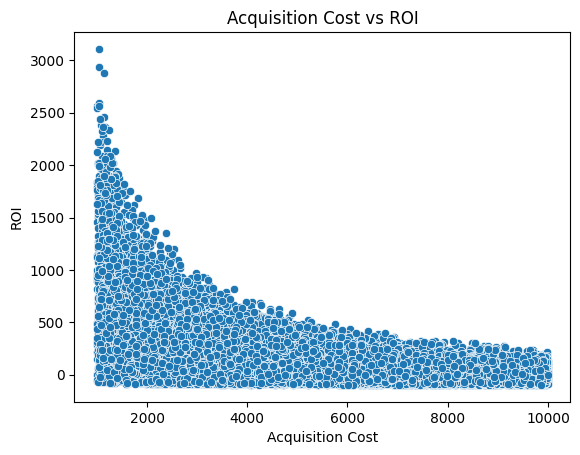

In [14]:
sns.scatterplot(data=df, x='Acquisition_Cost', y='ROI')
plt.title('Acquisition Cost vs ROI')
plt.xlabel('Acquisition Cost')
plt.ylabel('ROI')
plt.show()

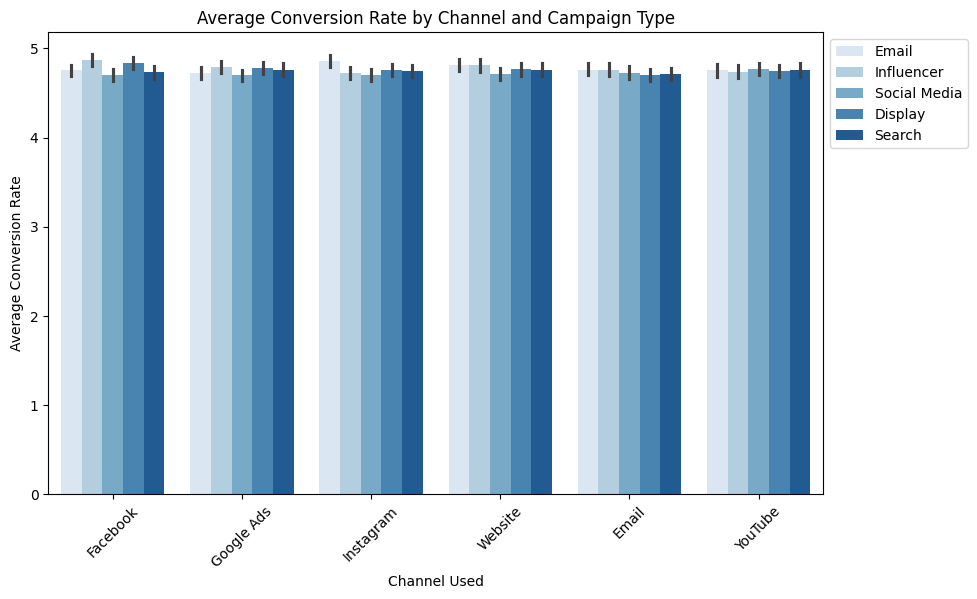

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Channel_Used', y='Conversion_Rate', hue='Campaign_Type',palette='Blues')

plt.title('Average Conversion Rate by Channel and Campaign Type')
plt.xlabel('Channel Used')
plt.ylabel('Average Conversion Rate')

plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

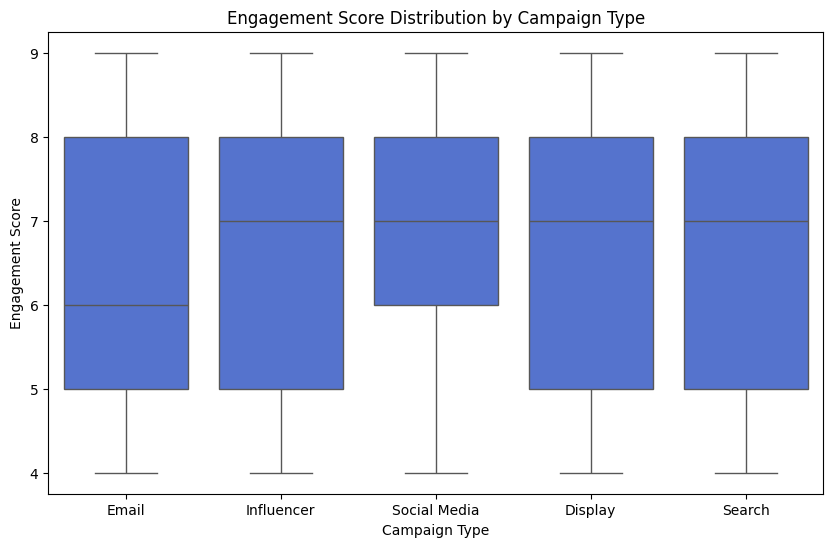

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Campaign_Type', y='Engagement_Score',color='royalblue')
plt.title('''Engagement Score Distribution by Campaign Type''')
plt.xlabel('Campaign Type')
plt.ylabel('Engagement Score')
plt.show()

/tmp/ipykernel_1787/1891232872.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a = sns.barplot(data=df, x='Company', y='ROI', palette='Set2')


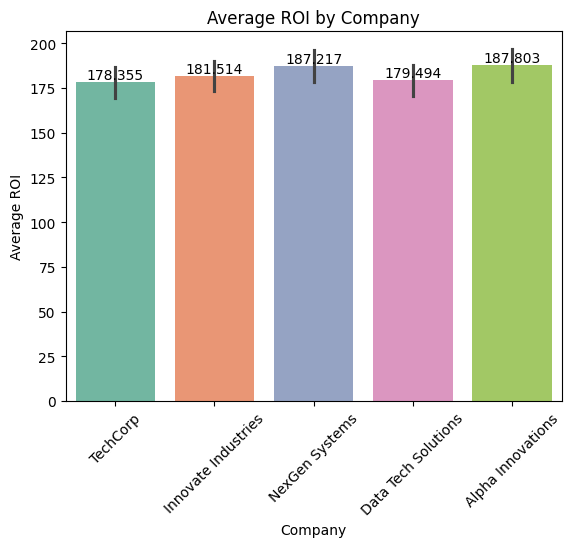

In [17]:
a = sns.barplot(data=df, x='Company', y='ROI', palette='Set2')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])
a.bar_label(a.containers[2])
a.bar_label(a.containers[3])
a.bar_label(a.containers[4])
plt.title('Average ROI by Company')
plt.xlabel('Company')
plt.ylabel('Average ROI')
plt.xticks(rotation=45)
plt.show()

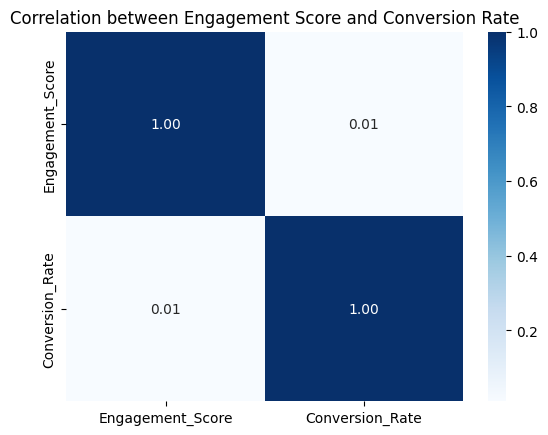

In [18]:
cor = df[['Engagement_Score','Conversion_Rate']].corr()
sns.heatmap(cor, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation between Engagement Score and Conversion Rate')
plt.show()

### **Customer Segmentation:**

/tmp/ipykernel_1787/1840250814.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  C = sns.countplot(data=df, x='Target_Audience', palette='Set2')


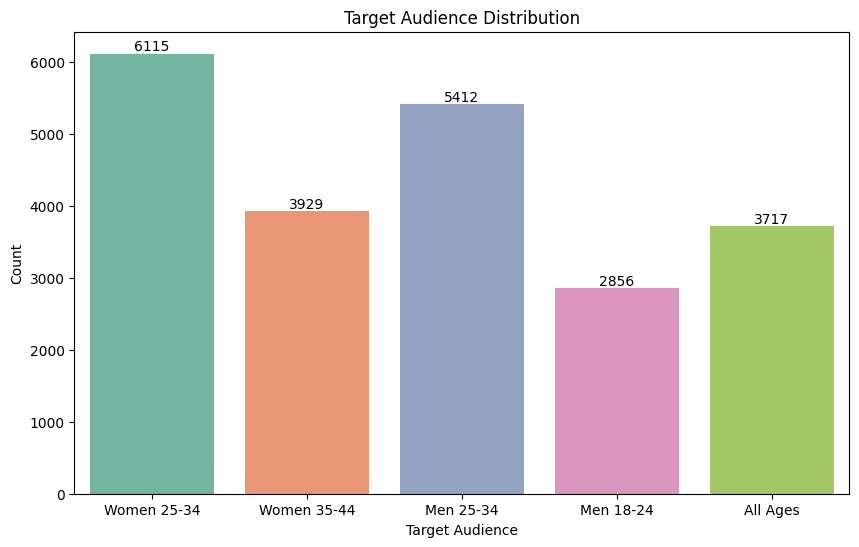

In [21]:
plt.figure(figsize=(10, 6))
C = sns.countplot(data=df, x='Target_Audience', palette='Set2')
C.bar_label(C.containers[0])
C.bar_label(C.containers[1])
C.bar_label(C.containers[2])
C.bar_label(C.containers[3])
C.bar_label(C.containers[4])
plt.title('Target Audience Distribution')
plt.xlabel('Target Audience')
plt.ylabel('Count')
plt.show()

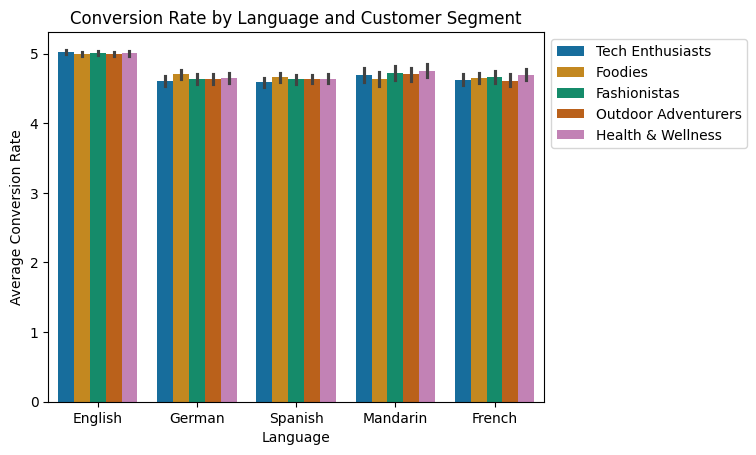

In [90]:
sns.barplot(data=df, x='Language', y='Conversion_Rate', hue='Customer_Segment', palette='colorblind')
plt.title('Conversion Rate by Language and Customer Segment')
plt.xlabel('Language')
plt.ylabel('Average Conversion Rate')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

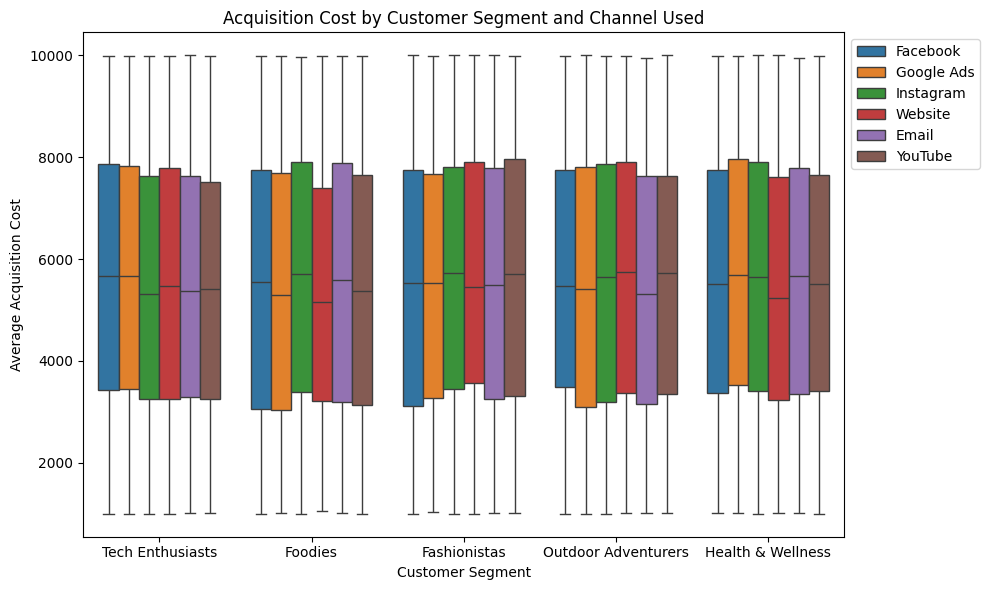

In [34]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='Customer_Segment', y='Acquisition_Cost', hue='Channel_Used')
plt.title('Acquisition Cost by Customer Segment and Channel Used')
plt.xlabel('Customer Segment')
plt.ylabel('Average Acquisition Cost')
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

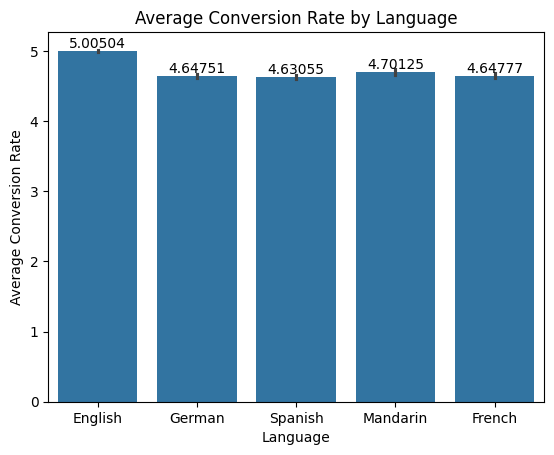

In [37]:
g = sns.barplot(data=df, x='Language', y='Conversion_Rate')
g.bar_label(g.containers[0])
plt.title('Average Conversion Rate by Language')
plt.xlabel('Language')
plt.ylabel('Average Conversion Rate')
plt.show()

### **Channel Eff ectiveness:**

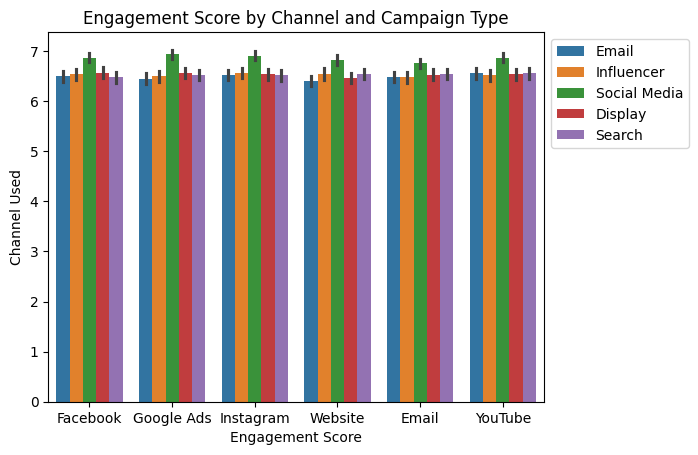

In [40]:
sns.barplot(data=df, x='Channel_Used', y='Engagement_Score', hue='Campaign_Type')
plt.title('Engagement Score by Channel and Campaign Type')
plt.xlabel('Engagement Score')
plt.ylabel('Channel Used')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

In [43]:
total = df.groupby('Channel_Used')['ROI'].sum().reset_index()
total

,Channel_Used,ROI
0,Email,673804.39
1,Facebook,704684.82
2,Google Ads,678232.24
3,Instagram,646462.11
4,Website,664577.42
5,YouTube,660542.33


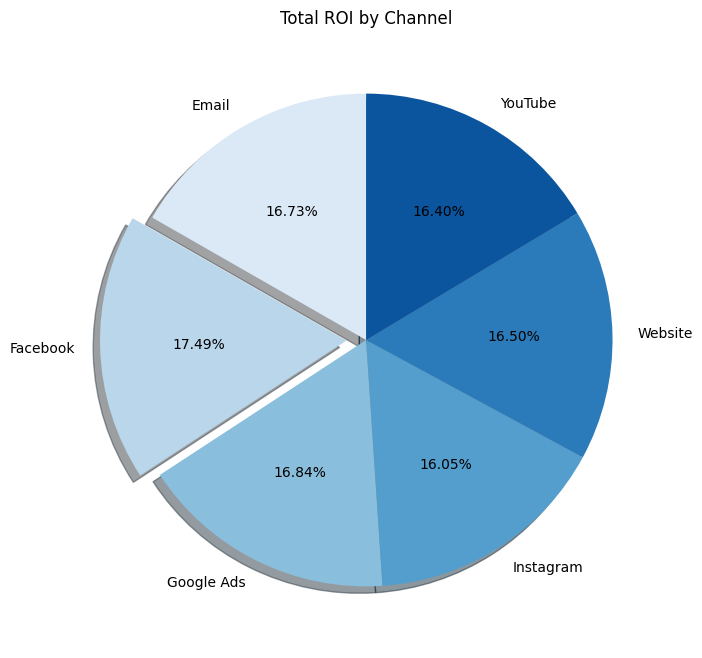

In [56]:
plt.figure(figsize=(8,8))

plt.pie(total['ROI'],
        labels=total['Channel_Used'],
        autopct='%1.2f%%',
        startangle=90,
        explode=[0,0.08,0,0,0,0],
        shadow=True,
        colors=sns.color_palette('Blues'),)
plt.title('Total ROI by Channel')
plt.show()

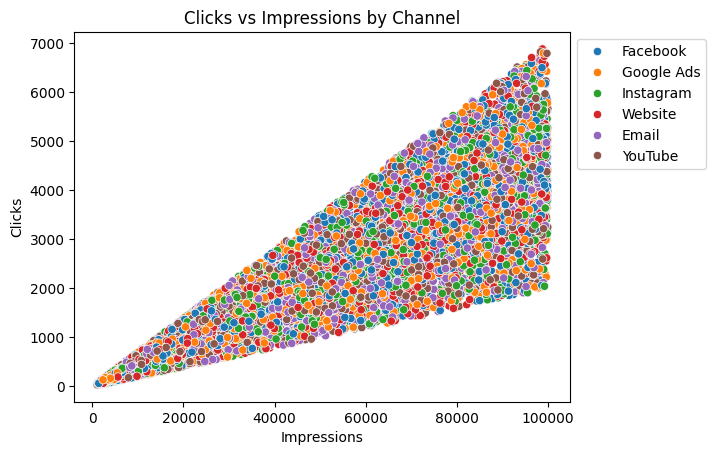

In [57]:
sns.scatterplot(data=df, x='Impressions', y='Clicks', hue='Channel_Used')
plt.title('Clicks vs Impressions by Channel')
plt.xlabel('Impressions')
plt.ylabel('Clicks')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

### **Time-Based Analysis:**

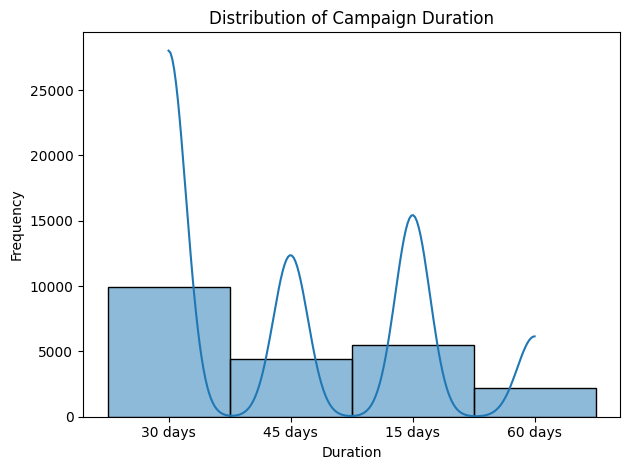

In [60]:
sns.histplot(data=df, x='Duration', kde=True)
plt.title('Distribution of Campaign Duration')
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [63]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

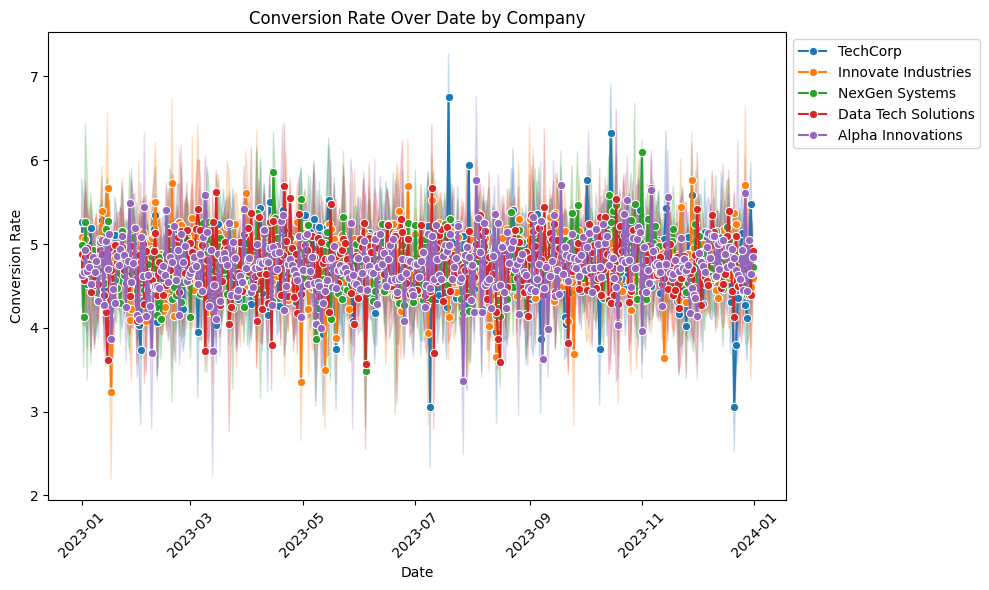

In [67]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Date', y='Conversion_Rate',hue='Company', marker='o')
plt.title('Conversion Rate Over Date by Company')
plt.xlabel('Date')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

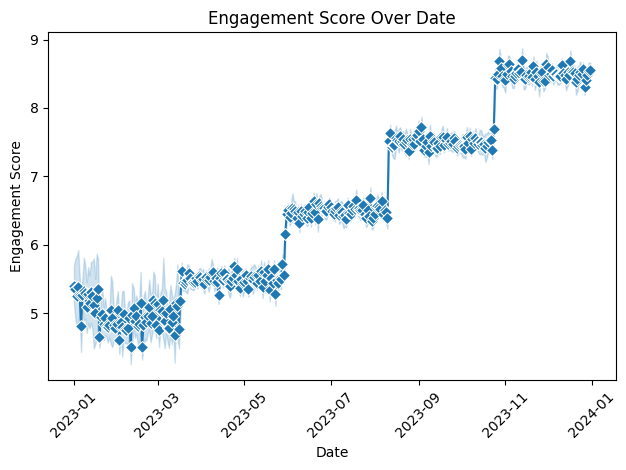

In [68]:
sns.lineplot(data=df, x='Date', y='Engagement_Score', marker='D')
plt.title('Engagement Score Over Date')
plt.xlabel('Date')
plt.ylabel('Engagement Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Geographic Analysis:**

/tmp/ipykernel_1787/1568280193.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Location', y='Acquisition_Cost', palette='Set2')


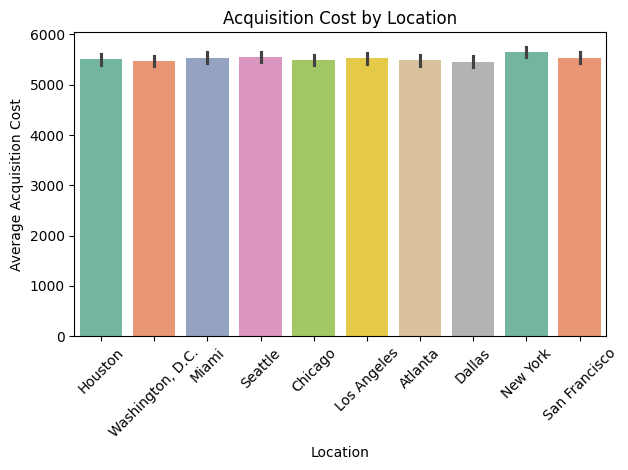

In [72]:
sns.barplot(data=df, x='Location', y='Acquisition_Cost', palette='Set2')
plt.title('Acquisition Cost by Location')
plt.xlabel('Location')
plt.ylabel('Average Acquisition Cost')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

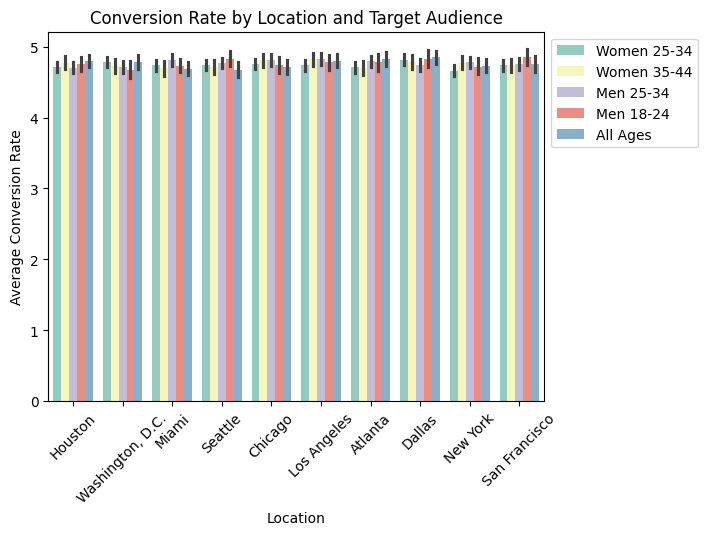

In [80]:
sns.barplot(data=df, x='Location', y='Conversion_Rate', hue='Target_Audience', palette='Set3')
plt.title('Conversion Rate by Location and Target Audience')
plt.xlabel('Location')
plt.ylabel('Average Conversion Rate')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

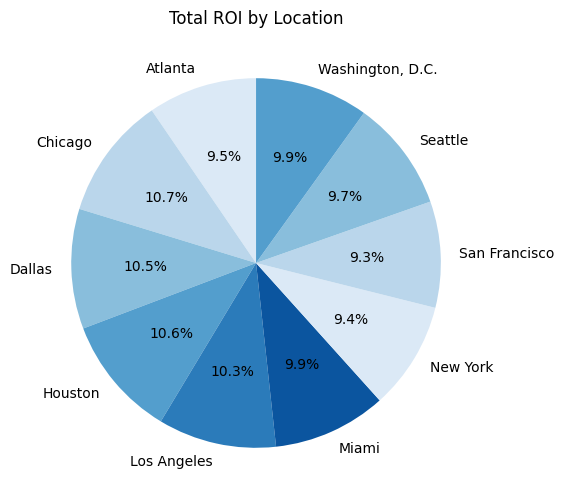

In [89]:
loca = df.groupby('Location')['ROI'].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.pie(x=loca['ROI'], labels=loca['Location'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Blues'))
plt.title('Total ROI by Location')
plt.show()